# Fine Tuning Small Language Model for Classification

Create Small Language Model (SLM) with GPT2 configuration, finetune GPT-2 model to classify input text into two classes - Spam or Non-Spam


The model layers are coded from scratch (including multi-head attention, layernorm, GELU, LoRA)
   GPT2 weights are loaded from open source model
   
This Small Language Model is used for binary classification and results evaluated:
   
       a) As-is without fine-tuning
       
       b) Parameter Efficient Fine Tuning (PEFT) - Frozen layers except last transformer block
       
       b) Parameter Efficient Fine Tuning (PEFT) - Finetuning GPT2 model with LoRA (low rank adaptation).
    
Loss function / Objective: Cross Entropy for logits of last output token

Optimization: AdamW

Evaluation: Accuracy of Spam not Spam Classification

Results: 
- The GPT2 model as is has ~ 50% accuracy
- With PEFT (last block unfrozen) the accuracy increases to ~87%
- With PEFT - LoRA we have ~92%
- LoRA is very efficient next to full model finetuning.
- Moreover, LoRA layers can be tuned for a specific task and added or removed as needed.
- This means we can train different LoRA layers for each task on the same base model and load them at inference time based on the usage


To Do:
- Multiclass classification
- Multilabel classification


Reference:
   - Data:
       - Donated on 6/21/2012 from UCIrvine Machine Learning Repository
     ```https://archive.ics.uci.edu/dataset/228/sms+spam+collection```
       - From Hugging face: ``` https://huggingface.co/datasets/ucirvine/sms_spam/blob/main/plain_text/train-00000-of-00001.parquet ```
   - GPT2 weights from: ``` https://openaipublic.blob.core.windows.net/gpt-2/models ```
   - Attention Is All You Need: ``` https://arxiv.org/abs/1706.03762 ```
   - LoRA: ``` https://arxiv.org/abs/2106.09685 ```
   - Andrej Karapathy: ```https://www.youtube.com/watch?v=kCc8FmEb1nY&list=PLAqhIrjkxbuWI23v9cThsA9GvCAUhRvKZ&index=7&pp=iAQB```
   - Sebastian Rashka: ```https://www.youtube.com/watch?v=5PFXJYme4ik```







In [1]:
from importlib.metadata import version
pkgs = ["matplotlib", # plotting library
        "numpy", # Pytorch and Tensorflow dependency
        "tiktoken", # Tokenizer
        "torch", # Deep learning library
        "tensorflow", # for OpenAI's pretrained weights
        "tqdm", # for progress bar
        "pandas" # dataset loading
        ]
for p in pkgs:
  print(f"{p} version: {version(p)}")

matplotlib version: 3.10.0
numpy version: 2.0.2
tiktoken version: 0.12.0
torch version: 2.10.0+cu128
tensorflow version: 2.19.0
tqdm version: 4.67.3
pandas version: 2.2.2


### Downloading the sms spam collection dataset from UC Irvine

In [ ]:
import urllib.request
import zipfile
import os
from pathlib import Path

url = "https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip"
zip_path = "sms_spam_collection.zip"
extracted_path = "sms_spam_collection"
data_file_path = Path(extracted_path) / "SMSSpamCollection.tsv"

def download_and_unzip_spam_data(url,
                                 zip_path,
                                 extracted_path,
                                 data_file_path):
  if data_file_path.exists():
    print(f"{data_file_path} already exists. Skipping download and extraction")
    return

  with urllib.request.urlopen(url) as response:
    with open(zip_path, "wb") as out_file:
      out_file.write(response.read())

  with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extracted_path)

  original_file_path = Path(extracted_path) / "SMSSpamCollection"
  os.rename(original_file_path, data_file_path)
  print(f"File downloaded and extracted to {data_file_path}")

download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path)


In [ ]:
import pandas as pd

df = pd.read_csv(data_file_path
                 , sep="\t"
                 , header=None
                 , names=["Label", "Text"])
print(df["Label"].value_counts())
df

In [ ]:
# Undersample majority class to balance dataset

def create_equal_balanced_dataset(df):
  num_spam = df[df["Label"] == "spam"].shape[0]
  ham_subset = df[df["Label"] == "ham"].sample(num_spam,
                                               random_state = 123)
  spam_subset = df[df["Label"]=="spam"]
  balanced_df = pd.concat([ham_subset, spam_subset])
  return balanced_df

balanced_df = create_equal_balanced_dataset(df)
print(balanced_df["Label"].value_counts())

# Convert Labels to integer tokens
balanced_df["Label"] = balanced_df["Label"].map({"ham": 0, "spam": 1})
print(balanced_df["Label"].value_counts())

### Read parquet file downloaded manual from Hugging Face
- Download file manually from hugging face location
url = "https://huggingface.co/datasets/ucirvine/sms_spam/blob/main/plain_text/train-00000-of-00001.parquet"

- Read the parquet file and rename the columns

In [3]:
import pandas as pd

parquet_path = "train-00000-of-00001.parquet"
df = pd.read_parquet(parquet_path)
df = df.rename(columns={"sms": "Text", "label": "Label"})
print(df["Label"].value_counts())

df


Label
0    4827
1     747
Name: count, dtype: int64


,Text,Label
0,"Go until jurong point, crazy.. Available only ...",0
1,Ok lar... Joking wif u oni...\n,0
2,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,U dun say so early hor... U c already then say...,0
4,"Nah I don't think he goes to usf, he lives aro...",0
...,...,...
5569,This is the 2nd time we have tried 2 contact u...,1
5570,Will ü b going to esplanade fr home?\n,0
5571,"Pity, * was in mood for that. So...any other s...",0
5572,The guy did some bitching but I acted like i'd...,0


In [ ]:
df

In [ ]:
data_file_path

PosixPath('sms_spam_collection/SMSSpamCollection.tsv')

### Undersample majority class to balance dataset

In [4]:
def create_equal_balanced_dataset(df):
  num_spam = df[df["Label"] == 1].shape[0]
  ham_subset = df[df["Label"] == 0].sample(num_spam,
                                               random_state = 123)
  spam_subset = df[df["Label"]==1]
  balanced_df = pd.concat([ham_subset, spam_subset])
  return balanced_df

balanced_df = create_equal_balanced_dataset(df)
print(balanced_df["Label"].value_counts())

# Convert Labels to integer tokens
#balanced_df["Label"] = balanced_df["Label"].map({"ham": 0, "spam": 1})
print(balanced_df["Label"].value_counts())

Label
0    747
1    747
Name: count, dtype: int64
Label
0    747
1    747
Name: count, dtype: int64


### Create Train Validate and Test datasets and Dataloader

In [5]:
def random_split(df, train_frac, validation_frac):
  len_df = len(df)
  df = df.sample(frac=1
                 , random_state=123).reset_index(drop=True)
  train_end = int(len_df * train_frac)
  validation_end = train_end + int(len_df * validation_frac)
  train_df = df[:train_end]
  validation_df = df[train_end:validation_end]
  test_df = df[validation_end:]
  return train_df, validation_df, test_df

train_df, validation_df, test_df = random_split(balanced_df
                                                  , 0.7, 0.1)
train_df.to_csv("train.csv", index=None)
validation_df.to_csv("validation.csv", index=None)
test_df.to_csv("test.csv", index=None)

print(f"number of training samples: {len(train_df)}\
          , validation: {len(validation_df)}\
          , test: {len(test_df)}")


number of training samples: 1045          , validation: 149          , test: 300


### Pytorch Dataset Class

Creating pytorch dataset class to
1. identifies the longest sequence in the training dataset
2. encodes the text messages
3. Pad all other sequences with a padding token to match length of the longest sequence ```padding token = [50256] for <|endoftext|>```
Pad to the length of longest message in the dataset



In [6]:
import tiktoken
tokenizer = tiktoken.get_encoding("gpt2")
print(tokenizer.encode("<|endoftext|>", allowed_special={"<|endoftext|>"}))

[50256]


In [7]:
import torch
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
class SpamDataset(Dataset):
  def __init__(self,
               csv_file,
               tokenizer,
               max_length=None,
               pad_token_id=50256):
    self.data = pd.read_csv(csv_file)
    self.encoded_texts = [tokenizer.encode(text) for text in self.data["Text"]]
    if max_length is None:
      self.max_length = self._longest_encoded_length()
    else:
      self.max_length = max_length
      self.encoded_texts = [encoded_text[:self.max_length]
                            for encoded_text in self.encoded_texts]

    self.encoded_texts = [encoded_text + [pad_token_id] *
                          (self.max_length - len(encoded_text))
                          for encoded_text in self.encoded_texts]



  def __getitem__(self, index):
    encoded = self.encoded_texts[index]
    label = self.data.iloc[index]["Label"]
    return(torch.tensor(encoded, dtype=torch.long),
           torch.tensor(label, dtype=torch.long))

  def __len__(self):
    return len(self.data)

  def _longest_encoded_length(self):
    max_length = 0
    for encoded_text in self.encoded_texts:
      encoded_length = len(encoded_text)
      if encoded_length > max_length:
        max_length = encoded_length
    return max_length



train_dataset = SpamDataset(csv_file="train.csv",
                            max_length=None,
                            tokenizer=tokenizer)
print(f"Max num of tokens: {train_dataset.max_length}")
val_dataset = SpamDataset(csv_file="validation.csv",
                          max_length=train_dataset.max_length,
                          tokenizer=tokenizer)
test_dataset = SpamDataset(csv_file="test.csv",
                           max_length=train_dataset.max_length,
                           tokenizer=tokenizer)

num_workers = 0
batch_size = 8
torch.manual_seed(123)
train_loader = DataLoader(dataset=train_dataset,
                          batch_size=batch_size,
                          shuffle=True,
                          num_workers=num_workers,
                          drop_last=True,)
val_loader = DataLoader(dataset=val_dataset,
                        batch_size=batch_size,
                        shuffle=True,
                        num_workers=num_workers,
                        drop_last=False,)
test_loader = DataLoader(dataset=test_dataset,
                         batch_size=batch_size,
                         num_workers=num_workers,
                         drop_last=False,)
# number of batches
print(f"{len(train_loader)} training batches")
print(f"{len(val_loader)} validation batches")
print(f"{len(test_loader)} test batches")
# number of samples in each batch
for input_batch, target_batch in train_loader:
  pass
print("Input batch dimensions:", input_batch.shape)
print("Label batch dimensions:", target_batch.shape)

Max num of tokens: 121
130 training batches
19 validation batches
38 test batches
Input batch dimensions: torch.Size([8, 121])
Label batch dimensions: torch.Size([8])


### Download Pre-trained GPT2 model and weights

In [8]:
import os
import json
import numpy as np
import tensorflow as tf
from tqdm import tqdm
import requests

def download_and_load_gpt2(model_size, models_dir):
  # validate model size
  allowed_sizes = ("124M", "355M", "774M", "1558M")
  if model_size not in allowed_sizes:
    raise ValueError(f"model size not in {allowed_sizes}")
  # Define model paths
  model_dir = os.path.join(models_dir, model_size)
  base_url = "https://openaipublic.blob.core.windows.net/gpt-2/models"
  backup_base_url = "https://f001.backblazeb2.com/file/LLMs-from-scratch/gpt2"
  filenames = ["checkpoint", "encoder.json", "hparams.json",
               "model.ckpt.data-00000-of-00001", "model.ckpt.index",
               "model.ckpt.meta", "vocab.bpe"]
  #Download files
  os.makedirs(model_dir, exist_ok=True)
  for filename in filenames:
    file_url = os.path.join(base_url, model_size, filename)
    backup_url = os.path.join(backup_base_url, model_size, filename)
    file_path = os.path.join(model_dir, filename)
    download_file(file_url, file_path, backup_url)

  # Load settings and params
  tf_ckpt_path = tf.train.latest_checkpoint(checkpoint_dir=model_dir)
  settings = json.load(open(os.path.join(model_dir, "hparams.json"), "r", encoding="utf-8"))
  params = load_gpt2_params_from_tf_ckpt(tf_ckpt_path, settings)

  return settings, params

def download_file(url, destination, backup_url=None):
  def _attempt_download(download_url):
    response = requests.get(download_url, stream=True, timeout=60)
    response.raise_for_status()

    file_size = int(response.headers.get("Content-Length", 0))

    # Check if file exists and has same size
    if os.path.exists(destination):
      file_size_local = os.path.getsize(destination)
      if file_size and file_size == file_size_local:
        print("File already exists and is up to date: {destination}")
        return True

    block_size = 1024 # 1KB
    desc = os.path.basename(download_url)
    with tqdm(total=file_size, unit="iB", unit_scale=True, desc=desc) as progress_bar:
      with open(destination, "wb") as file:
          for chunk in response.iter_content(chunk_size=block_size):
            if chunk:
              file.write(chunk)
              progress_bar.update(len(chunk))

    return True

  try:
    if _attempt_download(url):
      return
  except requests.exception.RequestException:
    if backup_url is not None:
      print(f"Primary URL ({url}) failed. Attempting backup URL: {backup_url}")
      try:
        if _attempt_download(backup_url):
          return
      except requests.exceptions.RequestException:
        pass

    error_message = (f"Failed to download from both primary URL: {url}"
                     f"{'and backup URL: '+ backup_url if backup_url else ''} "
                     "\n For help visit: https://github.com/rasbt/LLMs-from-scratch/discussions/273")
    print(error_message)
  except Exception as e:
    print(f"An unexpected error occurred: {e}")



def load_gpt2_params_from_tf_ckpt(ckpt_path, settings):
  # Initialize parameters dictionary with empty blocks for each layer
  params = {"blocks": [{} for _ in range(settings["n_layer"])]}

  # iterate over each variable in the checkpoint
  for name, _ in tf.train.list_variables(ckpt_path):
    # Load the variable and remove singleton dimensions
    variable_array = np.squeeze(tf.train.load_variable(ckpt_path, name))

    # Process the variable name to extract relevant parts
    variable_name_parts = name.split("/")[1:] # skip the 'model/' prefix

    # Identify the target dictionary for the variable
    target_dict = params
    if variable_name_parts[0].startswith("h"):
      layer_number = int(variable_name_parts[0][1:])
      target_dict = params["blocks"][layer_number]

    # recursively access or create nested dictionaries
    for key in variable_name_parts[1:-1]:
      target_dict = target_dict.setdefault(key, {})

    # Assign the variable array to the last key
    last_key = variable_name_parts[-1]
    target_dict[last_key] = variable_array

  return params







### Define GPT Model
Here we prepare classes to create off the shelf GPT-2 model with weights obtained from OpenAI server

Next we also define LoRA layers and modify the GPT-2 124M model with LoRA in Linear Layers. This allows us dual use of the GPT2 model. 1) Off the shelf mode for generative purposes 2) Add the trained LoRA layer to GPT-2 to use it as a classifier

GPT model is composed of transformer blocks, positional encoding, input tokens, output softmax layer

- transformer blocks
  - are composed of multihead self attention
  - composed of layer norms, feedforward layers and skip connections

- causal self attention: has query, key, values
  - Q and K combined with scaled dot product, masked and softmaxed to form attention scores
  - Post dropout combined with value to form attention weights


##### MultiHeadAttention

In [9]:
# define GPT2 model
import torch
import torch.nn as nn

# define multihead attention
class MultiHeadAttention(nn.Module):
  def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
    super().__init__()
    assert d_out % num_heads == 0, "d_out must be divisible by n_heads"

    self.d_out = d_out
    self.num_heads = num_heads
    self.head_dim = d_out // num_heads # reduce the projection dim to match the desired output dim

    self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
    self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
    self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
    self.out_proj = nn.Linear(d_out, d_out)
    self.dropout = nn.Dropout(dropout)
    self.register_buffer("mask", torch.triu(torch.ones(context_length, context_length), diagonal=1))

  def forward(self, x):
    b, num_tokens, d_in = x.shape
    keys = self.W_key(x) # Shape (b, num_tokens, d_out)
    queries = self.W_query(x) # Shape (b, num_tokens, d_out)
    values = self.W_value(x) # Shape (b, num_tokens, d_out)

    # implicitly split the matrix by adding num_heads dimension
    # dout -> num_heads x head_dim
    # => shape (b, num_tokens, d_out) -> (b, num_tokens, num_heads, head_dim)
    keys = keys.view(b, num_tokens, self.num_heads, self.head_dim)
    values = values.view(b, num_tokens, self.num_heads, self.head_dim)
    queries = queries.view(b, num_tokens, self.num_heads, self.head_dim)

    # Transpose: (b, num_tokens, num_heads, head_size) -> (b, num_heads, num_tokens, head_size)
    keys = keys.transpose(1, 2)
    queries = queries.transpose(1, 2)
    values = values.transpose(1, 2)

    # Compute scaled dot-product attention (aka self-attention) with a causal mask
    attn_scores = queries @ keys.transpose(-2, -1) # dot product for each head

    # original mask truncated to the number of token and converted to boolean
    mask_bool = self.mask.bool()[:num_tokens, :num_tokens]

    # use the mask to fill attention scores
    attn_scores.masked_fill_(mask_bool, -torch.inf)

    attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
    attn_weights = self.dropout(attn_weights)

    # shape: (b, num_tokens, num_heads, head_dim)
    context_vec = (attn_weights @ values).transpose(1, 2)

    # combine heads, where self.d_out = self.num_heads * self.head_dim
    context_vec = context_vec.reshape(b, num_tokens, self.d_out)
    context_vec = self.out_proj(context_vec) # optional projection

    return context_vec

##### LayerNorm, GELU activation, FeedForward Layers

In [10]:
# define feedforward, layernorm, activation layers
class LayerNorm(nn.Module):
  def __init__(self, emb_dim):
    super().__init__()
    self.eps = 1e-5
    self.scale = nn.Parameter(torch.ones(emb_dim))
    self.shift = nn.Parameter(torch.zeros(emb_dim))

  def forward(self, x):
    mean = x.mean(dim=-1, keepdim=True)
    var = x.var(dim=-1, keepdim=True, unbiased=False)
    norm_x = (x - mean) / torch.sqrt(var + self.eps)
    return self.scale * norm_x + self.shift

class GELU(nn.Module):
  def __init__(self):
    super().__init__()

  def forward(self, x):
    return 0.5 * x * (1 + torch.tanh(
        torch.sqrt(torch.tensor(2.0 / torch.pi)) *
        (x + 0.044715 * torch.pow(x, 3))
    ))

class FeedForward(nn.Module):
  def __init__(self, cfg):
    super().__init__()
    self.layers = nn.Sequential(
        nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),
        GELU(),
        nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"])
    )

  def forward(self, x):
    return self.layers(x)


##### Transformer Block

In [11]:
# define transformer block
class TransformerBlock(nn.Module):
  def __init__(self, cfg):
    super().__init__()
    self.att = MultiHeadAttention(
        d_in=cfg["emb_dim"],
        d_out=cfg["emb_dim"],
        context_length=cfg["context_length"],
        num_heads=cfg["n_heads"],
        dropout=cfg["drop_rate"],
        qkv_bias=cfg["qkv_bias"]
    )
    self.ff = FeedForward(cfg)
    self.norm1 = LayerNorm(cfg["emb_dim"])
    self.norm2 = LayerNorm(cfg["emb_dim"])
    self.drop_resid = nn.Dropout(cfg["drop_rate"])


  def forward(self, x):
    # shortcut connection for attention block
    shortcut = x
    x = self.norm1(x)
    x = self.att(x)
    x = self.drop_resid(x)
    x = x + shortcut # add the original input

    # shortcut connection for feed-forward block
    shortcut = x
    x = self.norm2(x)
    x = self.ff(x)
    x = self.drop_resid(x)
    x = x + shortcut # add the original input

    return x

##### GPT2 Config Model 124M Parameters

In [12]:

# define model with GPT2 configurations
class GPTModel(nn.Module):
  def __init__(self, cfg):
    super().__init__()
    self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
    self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
    self.drop_emb = nn.Dropout(cfg["drop_rate"])

    self.trf_blocks = nn.Sequential(*[TransformerBlock(cfg) \
                                      for _ in range(cfg["n_layers"])])
    self.final_norm = LayerNorm(cfg["emb_dim"])
    self.out_head = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias=False)


  def forward(self, in_idx):
    batch_size, seq_len = in_idx.shape
    tok_embeds = self.tok_emb(in_idx)
    pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))
    x = tok_embeds + pos_embeds # shape (batch, num_tokens, emb_size)
    x = self.drop_emb(x)
    x = self.trf_blocks(x)
    x = self.final_norm(x)
    logits = self.out_head(x)
    return logits




##### LoRA Layer - Low Rank Adaptation for Linear Layers

In [13]:
class LoRALayer(nn.Module):
    def __init__(self, in_dim, out_dim, rank, alpha):
        super().__init__()
        self.A = nn.Parameter(torch.empty(in_dim, rank))
        nn.init.kaiming_uniform_(self.A, a=math.sqrt(5))
        self.B = nn.Parameter(torch.zeros(rank, out_dim))
        self.alpha = alpha

    def forward(self, x):
        x = self.alpha * (x @ self.A @ self.B)
        return x

class LinearWithLoRA(nn.Module):
    def __init__(self, linear, rank, alpha):
        super().__init__()
        self.linear = linear
        self.lora = LoRALayer(linear.in_features, linear.out_features, rank, alpha)

    def forward(self, x):
        return self.linear(x) + self.lora(x)

def replace_linear_with_lora(model, rank, alpha):
    for name, module in model.named_children():
        if isinstance(module, nn.Linear):
            # Add LoRA weights (LoRAW) to linear layer fully connected weights W - W + LoRAW
            # Do this by replacing original linear layer with linear with lora
            setattr(model, name, LinearWithLoRA(module, rank, alpha))
        else:
            # Recursively apply the replacement to child modules
            replace_linear_with_lora(module, rank, alpha)

### Load Weights to GPT Model

In [14]:
def assign(left, right):
  if left.shape != right.shape:
    raise ValueError(f"Shape mismatch. Left: {left.shape}, Right: {right.shape}")
  return torch.nn.Parameter(torch.tensor(right))

# load weights into gpt2 model
def load_weights_into_gpt(gpt, params):
  gpt.pos_emb.weight = assign(gpt.pos_emb.weight, params["wpe"])
  gpt.tok_emb.weight = assign(gpt.tok_emb.weight, params["wte"])

  for b in range(len(params["blocks"])):
    q_w, k_w, v_w = np.split((params["blocks"][b]["attn"]["c_attn"])["w"],
                             3,
                             axis=-1)
    gpt.trf_blocks[b].att.W_query.weight = assign(gpt.trf_blocks[b].att.W_query.weight,
                                                  q_w.T)
    gpt.trf_blocks[b].att.W_key.weight = assign(gpt.trf_blocks[b].att.W_key.weight,
                                                k_w.T)
    gpt.trf_blocks[b].att.W_value.weight = assign(gpt.trf_blocks[b].att.W_value.weight,
                                                  v_w.T)

    q_b, k_b, v_b = np.split((params["blocks"][b]["attn"]["c_attn"])["b"],
                             3,
                             axis=-1)
    gpt.trf_blocks[b].att.W_query.bias = assign(gpt.trf_blocks[b].att.W_query.bias,
                                                q_b)
    gpt.trf_blocks[b].att.W_key.bias = assign(gpt.trf_blocks[b].att.W_key.bias,
                                              k_b)
    gpt.trf_blocks[b].att.W_value.blias = assign(gpt.trf_blocks[b].att.W_value.bias,
                                                 v_b)

    gpt.trf_blocks[b].att.out_proj.weight = assign(gpt.trf_blocks[b].att.out_proj.weight,
                                                   params["blocks"][b]["attn"]["c_proj"]["w"].T)
    gpt.trf_blocks[b].att.out_proj.bias = assign(gpt.trf_blocks[b].att.out_proj.bias,
                                                 params["blocks"][b]["attn"]["c_proj"]["b"])

    gpt.trf_blocks[b].ff.layers[0].weight = assign(gpt.trf_blocks[b].ff.layers[0].weight,
                                                   params["blocks"][b]["mlp"]["c_fc"]["w"].T)
    gpt.trf_blocks[b].ff.layers[0].bias = assign(gpt.trf_blocks[b].ff.layers[0].bias,
                                                 params["blocks"][b]["mlp"]["c_fc"]["b"])
    gpt.trf_blocks[b].ff.layers[2].weight = assign(gpt.trf_blocks[b].ff.layers[2].weight,
                                                   params["blocks"][b]["mlp"]["c_proj"]["w"].T)
    gpt.trf_blocks[b].ff.layers[2].bias = assign(gpt.trf_blocks[b].ff.layers[2].bias,
                                                 params["blocks"][b]["mlp"]["c_proj"]["b"])

    gpt.trf_blocks[b].norm1.scale = assign(gpt.trf_blocks[b].norm1.scale,
                                           params["blocks"][b]["ln_1"]["g"])
    gpt.trf_blocks[b].norm1.shift = assign(gpt.trf_blocks[b].norm1.shift,
                                           params["blocks"][b]["ln_1"]["b"])
    gpt.trf_blocks[b].norm2.scale = assign(gpt.trf_blocks[b].norm2.scale,
                                           params["blocks"][b]["ln_2"]["g"])
    gpt.trf_blocks[b].norm2.shift = assign(gpt.trf_blocks[b].norm2.shift,
                                           params["blocks"][b]["ln_2"]["b"])

    gpt.final_norm.scale = assign(gpt.final_norm.scale, params["g"])
    gpt.final_norm.shift = assign(gpt.final_norm.shift, params["b"])
    gpt.out_head.weight = assign(gpt.out_head.weight, params["wte"])

### Instantiate Model and Load Weights

In [15]:
BASE_CONFIG = {"vocab_size": 50257,
                   "context_length": 1024,
                   "drop_rate": 0.0,
                   "qkv_bias": True}
CHOOSE_MODEL = "gpt2-small (124M)"

def instantiate_model(choose_model="gpt2-small (124M)", load_weights=True):

    model_size = {"gpt2-small (124M)": "124M",
                     "gpt2-medium (355M)": "355M",
                     "gpt2-large (774M)": "774M",
                     "gpt2-xl (1558M)": "1558M"}

    model_configs = {"gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
                     "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
                     "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
                     "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25}}

    if not load_weights:
        torch.manual_seed(123)

    BASE_CONFIG.update(model_configs[choose_model])
    model = GPTModel(BASE_CONFIG)

    if load_weights:
        settings, params = download_and_load_gpt2(model_size=model_size[choose_model], models_dir="gpt2")
        load_weights_into_gpt(model, params)

    model.eval()
    return model


# Check Weights loaded right with GPT2 Text Generation

### Generate text with tempeature scaling and beam search



In [88]:
def generate(model, idx, max_new_tokens, context_size, temperature=0.0, top_k=None, eos_id=None):
  # for loop is the same as before: get logits and only focus on the last step
  for _ in range(max_new_tokens):
    idx_cond = idx[:, -context_size:]
    with torch.no_grad():
      logits = model(idx_cond)
    logits = logits[:, -1, :]

    # Filter logits with top_k sampling
    if top_k is not None:
      # Keep only k values
      top_logits, _ = torch.topk(logits, top_k)
      min_val = top_logits[:, -1]
      logits = torch.where(logits < min_val,
                           torch.tensor(float("-inf")).to(logits.device),
                           logits)

    # Apply temperature scaling
    if temperature > 0.0:
      logits = logits / temperature

      # numerical stability tip to get equivalent results on mps device
      # subtract rowwise max before softmax
      logits = logits - logits.max(dim=-1, keepdim=True).values

      # apply softmax to get probabilities
      probs = torch.nn.multinomial(probs, num_samples=1) # (batch_size, 1)

    # Otherwise same as before: get idx of the vocabulary with the highest logits values
    else:
      idx_next = torch.argmax(logits, dim=-1, keepdim=True) # batch_size, 1

    if idx_next == eos_id: # stop generating early if end of seq token
      break

    # apend sampled index to the runnin sequence
    idx = torch.cat((idx, idx_next), dim=1) # batch_size, num_tokens+1
  return idx


### Generate text from model

In [81]:
def text_to_token_ids(text, tokenizer):
  encoded = tokenizer.encode(text, allowed_special={"<|endoftext|>"})
  encoded_tensor = torch.tensor(encoded).unsqueeze(0) # add batch dimension
  return encoded_tensor

def token_ids_to_text(token_ids, tokenizer):
  flat = token_ids.squeeze(0) # remove batch dimension
  return tokenizer.decode(flat.tolist())

def generate_text(model, idx, max_new_tokens, context_size):
  # idx is (B, T) array if indices in the current context
  for _ in range(max_new_tokens):
    # crop context if it exceeds the supported context size
    # If LLM supports only 5 tokens and the context_size is 10
    # then only the last 5 tokens are used as context
    idx_cond = idx[:, -context_size:]

    # get the predictions
    with torch.no_grad():
      logits = model(idx_cond)

    # focys only on the last time step
    # (batch, n_token, vocab_size) becomes (batch, vocab_size)
    logits = logits[:, -1, :]

    # get the idx of the vocab entry with the highest logits value
    idx_next = torch.argmax(logits, dim=-1, keepdim=True) # (batch, 1)

    # append sampled index to the running sequence
    idx = torch.cat((idx, idx_next), dim=1) # (batch, n_tokens+1)

  return idx

In [82]:
model = instantiate_model()

CHOOSE_MODEL = "gpt2-small (124M)"
INPUT_PROMPT = "Every effort moves"

text1 = "Every effort moves you"
token_ids = generate_text(model=model,
                                 idx=text_to_token_ids(text1, tokenizer),
                                 max_new_tokens=15,
                                 context_size=BASE_CONFIG["context_length"])
print(token_ids_to_text(token_ids, tokenizer))

Every effort moves you forward.

"I'm not going to sit here and say that


In [ ]:
text2 = ("Is the following text 'spam'? Answer with 'yes' or 'no':"
         "'You are a winner you have been specially "
         "selected to recieve $1000 cash or a $2000 award'")
token_ids = generate_text(model=model, idx=text_to_token_ids(text2, tokenizer),
                          max_new_tokens=23,
                          context_size=BASE_CONFIG["context_length"])
print(token_ids_to_text(token_ids, tokenizer))

# GPT2 Model Performance to classify input text - Without FineTuning

### Loss Calculation
```model.eval()``` Changes model from training mode to evaluation mode puts model to evaluation mode.
It changes the behavior of layers that act different during training versus inference - Dropout Layer, Batch Normalization Layer
1. Dropout Layers
    - In Training: Randomly zero out dropout rate % of neurons to prevent overfitting. Forces network to learn redundant representations.
    - In Evaluation: Dropout is deactivated. All neurons are used, and weights are typically scaled to account for  all connections, are now active. This ensures the output is deterministic.

2. Batch Normalization Layers
    - In Training: Calculates mean and variance of the current mini-batch to normalize the data. It also updates a "running estimate" of the global mean and variance.
    - In Evaluation: Stops updating the running estimates. It uses the saved global mean and variance (learned during training) to normalize the input. This ensures that a single test record is processed using the statistical context of the entire training set, rather than just itself.

```torch.no_grad()``` Disables gradient calculation (disables memory usage and gradient tracking)


In [18]:
def calc_loss_batch(input_batch, target_batch, model, device,
                    trainable_token_pos=-1, ignore_index=-100,
                    average_embedding=False):
    input_batch = input_batch.to(device)
    target_batch = target_batch.to(device)
    if trainable_token_pos == "flexible": # selects the last token before the padding tokens
        # find last non-padding token for each sequence in the batch
        pad_token_id = 50256
        mask = input_batch != pad_token_id
        last_token_pos = mask.sum(dim=1) - 1 # get position of last real token
        logits = model(input_batch) # shape: [batch_size, seq_len, num_classes]
        batch_size = logits.size(0)
        selected_logits = logits[torch.arange(batch_size), last_token_pos]
        loss = torch.nn.functional.cross_entropy(selected_logits, target_batch)
        return loss
    else:
        logits = model(input_batch)
        if average_embedding:
            logits = logits.mean(dim=1) # average over the sequence dimension (dim=1)
        else:
            logits = logits[:, trainable_token_pos, :] # logits of last output token
        loss = torch.nn.functional.cross_entropy(logits, target_batch)
        return loss

def calc_loss_loader(data_loader, model, device, num_batches=None,
                     trainable_token_pos=-1, ignore_index=-100,
                     average_embedding=False):
    total_loss = 0
    if len(data_loader) == 0:
        return float("nan")
    elif num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))

    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_loss_batch(input_batch, target_batch, model, device,
                                   trainable_token_pos=trainable_token_pos, ignore_index=ignore_index,
                                   average_embedding=average_embedding)
            total_loss += loss.item()
        else:
            break
    return total_loss / num_batches

### Evaluate Model

In [19]:
def evaluate_model(model, train_loader, val_loader, device,
                  eval_iter, trainable_token_pos=-1,
                  ignore_index=-100, average_embedding=False):
    model.eval()
    with torch.no_grad():
      train_loss = calc_loss_loader(train_loader, model, device,
                                    num_batches=eval_iter,
                                    trainable_token_pos=trainable_token_pos,
                                    ignore_index=ignore_index,
                                    average_embedding=average_embedding)
      val_loss = calc_loss_loader(val_loader, model, device,
                                  num_batches=eval_iter, trainable_token_pos=trainable_token_pos,
                                  ignore_index=ignore_index,
                                  average_embedding=average_embedding)
    model.train()
    return train_loss, val_loss

### Calculate Accuracy


In [20]:
def calc_accuracy_loader(data_loader, model, device, num_batches=None,
                         trainable_token_pos=-1, average_embedding=False):
    model.eval()
    correct_prediction, num_examples = 0, 0
    if num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))

    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            input_batch = input_batch.to(device)
            target_batch = target_batch.to(device)
            # stop gradient calculation
            with torch.no_grad():
                logits = model(input_batch)
            if trainable_token_pos ==  'flexible':
                pad_token_id = 50256 # token used for padding <|endoftext|>
                mask = input_batch != pad_token_id
                last_token = mask.sum(dim=1) - 1 # position of last real token
                batch_size = logits.size(0)
                selected_logits = logits[torch.arange(batch_size), last_token_pos]
            elif average_embedding:
                selected_logits = logits.mean(dim=1)
            else:
                selected_logits = logits[:,trainable_token_pos,:] # logits of last output token

            predicted_label = torch.argmax(selected_logits, dim=-1)
            num_examples += predicted_label.shape[0]
            correct_prediction += (predicted_label==target_batch).sum().item()
        else:
            break
    return correct_prediction / num_examples


### Pretrained GPT2 Model Accuracy

In [86]:
# run evaluations prior to training
torch.manual_seed(123)
with torch.no_grad():
    train_loss = calc_loss_loader(train_loader, model, device, num_batches=10)
    val_loss = calc_loss_loader(val_loader, model, device, num_batches=10)
    test_loss = calc_loss_loader(test_loader, model, device, num_batches=10)
    train_accuracy = calc_accuracy_loader(train_loader, model, device, num_batches=100)
    val_accuracy = calc_accuracy_loader(val_loader, model, device, num_batches=100)
    test_accuracy = calc_accuracy_loader(test_loader, model, device, num_batches=100)

print(f"Training loss: {train_loss:.3f}")
print(f"Validation loss: {val_loss:.3f}")
print(f"Test loss: {test_loss:.3f}")

print(f"Training accuracy: {train_accuracy*100:.2f}")
print(f"Validation accuracy: {val_accuracy*100:.2f}")
print(f"Test accuracy: {test_accuracy*100:.2f}")

Training loss: 3.636
Validation loss: 4.283
Test loss: 3.882
Training accuracy: 51.00
Validation accuracy: 46.98
Test accuracy: 49.67


# Fine-tuning SLM-GPT2 to classify input text with PEFT 

### Prepare model for classification tuning - PEFT (parameter efficient fine-tuning)
##### Freeze model layers
##### Add classification head
##### Unfreeze last transformer block and last layer norm
##### Add LoRA to Linear Layers - only keep lora weights unfrozen

In [29]:
import math
def prep_model_for_classification(model, train_only_last_block=True, train_all_layers=False, add_lora=False):

    # new layers added has requires_grad=True by default
    num_classes = 2
    model.out_head = torch.nn.Linear(in_features=BASE_CONFIG["emb_dim"],
                                    out_features=num_classes)

    if train_only_last_block:
        # Freeze model parameters and add a classification layer
        for param in model.parameters():
            param.requires_grad = False

        #Experiments show that just the last layer training is less efficient
        # Set the last layer and last block to trainable
        for param in model.trf_blocks[-1].parameters():
            param.requires_grad = True
        for param in model.final_norm.parameters():
            param.requires_grad = True

    elif add_lora:
        # Freeze model parameters and add a classification layer
        for param in model.parameters():
            param.requires_grad = False
        replace_linear_with_lora(model, rank=16, alpha=16)
    elif train_all_layers:
        pass
    else:
        raise ValueError("trainable layer arguments unclear")
    return model

### PEFT - Frozen layer except last transformer block

##### GPT2 124M Model with only Last transformer block unfrozen (rest are frozen Layers)

In [17]:
model = instantiate_model()
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total trainable parameters before: {total_params}")
print(model)
'''for name, param in model.named_parameters():
    print(f"before {name}: {param.requires_grad}")'''
model = prep_model_for_classification(model)
for name, param in model.named_parameters():
    print(f"after {name}: {param.requires_grad}")
print(model)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total trainable LoRA parameters: {total_params}")

device  = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

checkpoint: 100%|██████████| 77.0/77.0 [00:00<00:00, 144kiB/s]
encoder.json: 100%|██████████| 1.04M/1.04M [00:01<00:00, 654kiB/s]
hparams.json: 100%|██████████| 90.0/90.0 [00:00<00:00, 192kiB/s]
model.ckpt.data-00000-of-00001: 100%|██████████| 498M/498M [02:18<00:00, 3.60MiB/s]
model.ckpt.index: 100%|██████████| 5.21k/5.21k [00:00<00:00, 5.33MiB/s]
model.ckpt.meta: 100%|██████████| 471k/471k [00:01<00:00, 388kiB/s]
vocab.bpe: 100%|██████████| 456k/456k [00:01<00:00, 321kiB/s]


Total trainable parameters before: 163046400
GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.0, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_resid): Dropout(p=0.0, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttentio

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.0, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_resid): Dropout(p=0.0, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768,

In [21]:
def train_classifier(model, train_loader, val_loader, optimizer, device,
                     num_epochs, eval_freq, eval_iter,
                     max_steps=None, trainable_token_pos=-1,
                     accumulation_steps=1, ignore_index=-100,
                     average_embedding=False):
    train_losses, val_losses, train_acc, val_acc = [], [], [], []
    examples_seen = 0
    global_step = -1
    for epoch in range(num_epochs):
        model.train() # set model in training mode

        for batch_idx, (input_batch, target_batch) in enumerate(train_loader):

            loss = calc_loss_batch(input_batch, target_batch, model, device,
                                   trainable_token_pos=trainable_token_pos,
                                   ignore_index=ignore_index,
                                   average_embedding=average_embedding)
            # use gradient accumulation if accumulation_steps > 1
            loss /= accumulation_steps
            loss.backward() # calculate loss gradients
            is_update_step = (((batch_idx + 1) % accumulation_steps) == 0) \
                                or ((batch_idx + 1) == len(train_loader))
            if is_update_step:
                optimizer.step() # update model weigths
                optimizer.zero_grad() # reset loss gradients to zero

            examples_seen += input_batch.shape[0]
            global_step += 1

            # Evaluation step called at evaluation frequency
            if  global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(model, train_loader, val_loader,
                                                      device, eval_iter,
                                                      trainable_token_pos=trainable_token_pos,
                                                      ignore_index=ignore_index,
                                                      average_embedding=average_embedding)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                print(f"Ep {epoch+1} (Step {global_step:06d}):"
                      f"Train loss {train_loss:.3f}, Val loss {val_loss:.3f}")
                if max_steps is not None and global_step > max_steps:
                    break
            # Calculate accuracy after each epoch
            train_accuracy = calc_accuracy_loader(train_loader, model, device,
                                                  num_batches=eval_iter,
                                                  trainable_token_pos=trainable_token_pos,
                                                  average_embedding=average_embedding)
            val_accuracy = calc_accuracy_loader(val_loader, model, device,
                                                num_batches=eval_iter,
                                                trainable_token_pos=trainable_token_pos,
                                                average_embedding=average_embedding)
            train_acc.append(train_accuracy)
            val_acc.append(val_accuracy)
            print(f"Training accuracy: {train_accuracy*100:.2f} | ", end="")
            print(f"Validation accuracy: {val_accuracy*100:.2f}")

            if max_steps is not None and global_step > max_steps:
                break
        return train_losses, val_losses, train_acc, val_acc, examples_seen

##### optimization

In [22]:
import time
start_time = time.time()
torch.manual_seed(123)
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=0.1)
num_epochs = 5
train_losses, val_losses, train_acc, val_acc, examples_seen = \
    train_classifier(model, train_loader, val_loader, optimizer, device,
                     num_epochs=num_epochs, eval_freq=50, eval_iter=100,
                     max_steps=None, trainable_token_pos=-1,
                     accumulation_steps=1, ignore_index=-100,
                     average_embedding=False)
end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f"Training completed in {execution_time_minutes:.2f} minutes")

Ep 1 (Step 000000):Train loss 3.079, Val loss 2.733
Training accuracy: 50.00 | Validation accuracy: 53.02
Training accuracy: 50.75 | Validation accuracy: 53.02
Training accuracy: 48.12 | Validation accuracy: 51.68
Training accuracy: 40.00 | Validation accuracy: 44.97
Training accuracy: 32.88 | Validation accuracy: 30.20
Training accuracy: 24.00 | Validation accuracy: 18.79
Training accuracy: 19.62 | Validation accuracy: 15.44
Training accuracy: 19.50 | Validation accuracy: 15.44
Training accuracy: 18.12 | Validation accuracy: 16.78
Training accuracy: 22.00 | Validation accuracy: 20.13
Training accuracy: 22.75 | Validation accuracy: 20.81
Training accuracy: 24.62 | Validation accuracy: 25.50
Training accuracy: 27.00 | Validation accuracy: 25.50
Training accuracy: 27.50 | Validation accuracy: 28.19
Training accuracy: 30.38 | Validation accuracy: 28.86
Training accuracy: 30.88 | Validation accuracy: 28.86
Training accuracy: 30.38 | Validation accuracy: 28.86
Training accuracy: 32.25 | Val

### Plot classification loss

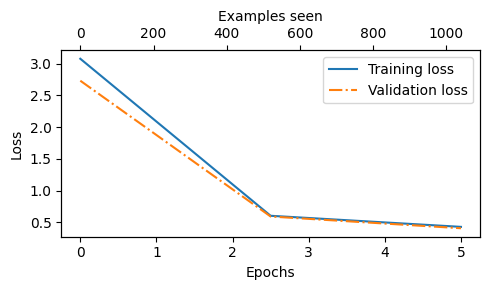

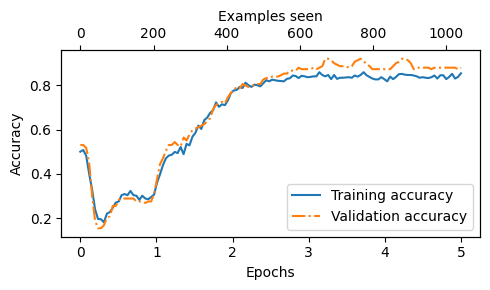

In [23]:
import matplotlib.pyplot as plt
def plot_values(epochs_seen, examples_seen,
                train_values, val_values,
                label="loss"):
    fig, ax1 = plt.subplots(figsize=(5, 3))
    # plots training and validation loss by epochs
    ax1.plot(epochs_seen, train_values, label=f"Training {label}")
    ax1.plot(epochs_seen, val_values, linestyle="-.",
             label=f"Validation {label}")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel(label.capitalize())
    ax1.legend()

    # create a second x-axis for examples seen
    ax2 = ax1.twiny()
    ax2.plot(examples_seen, train_values, alpha=0) # invisible plot for aligning ticks
    ax2.set_xlabel("Examples seen")

    fig.tight_layout() # adjust layout
    plt.savefig(f"{label}-plot.pdf")
    plt.show()

epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
examples_seen_tensor = torch.linspace(0, examples_seen, len(train_losses))
plot_values(epochs_tensor, examples_seen_tensor, train_losses, val_losses)

epochs_tensor = torch.linspace(0, num_epochs, len(train_acc))
examples_seen_tensor = torch.linspace(0, examples_seen, len(train_acc))

plot_values(epochs_tensor, examples_seen_tensor, train_acc, val_acc,
            label="accuracy")

In [25]:
# run evaluations post training - fine-tuning last block
torch.manual_seed(123)
with torch.no_grad():
    train_loss = calc_loss_loader(train_loader, model, device, num_batches=10)
    val_loss = calc_loss_loader(val_loader, model, device, num_batches=10)
    test_loss = calc_loss_loader(test_loader, model, device, num_batches=10)
    train_accuracy = calc_accuracy_loader(train_loader, model, device, num_batches=100)
    val_accuracy = calc_accuracy_loader(val_loader, model, device, num_batches=100)
    test_accuracy = calc_accuracy_loader(test_loader, model, device, num_batches=100)

print(f"Training loss: {train_loss:.3f}")
print(f"Validation loss: {val_loss:.3f}")
print(f"Test loss: {test_loss:.3f}")

print(f"Training accuracy: {train_accuracy*100:.2f}")
print(f"Validation accuracy: {val_accuracy*100:.2f}")
print(f"Test accuracy: {test_accuracy*100:.2f}")

Training loss: 0.356
Validation loss: 0.282
Test loss: 0.367
Training accuracy: 85.38
Validation accuracy: 87.92
Test accuracy: 87.67


# Finetuning Pretrained SLM - GPT2 for classification with LoRA
 - 2 class classification  modify last block for last token
 - multiclass classification modify last block for last token
 - multiclass classification modify all blocks for last token
 - multiclass classification add LoRA all blocks for last token
 - multiclass classification with DistilBERT LoRA all blocks for last token

### Optimization with PEFT - Low Rank Adaptation (LoRA)

In [30]:
model = instantiate_model()
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total trainable parameters before: {total_params}")
#print(model)
'''for name, param in model.named_parameters():
    print(f"before {name}: {param.requires_grad}")'''
model = prep_model_for_classification(model, train_only_last_block=False,
                                      train_all_layers=False,
                                      add_lora=True )
for name, param in model.named_parameters():
    print(f"after {name}: {param.requires_grad}")
print(model)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total trainable LoRA parameters: {total_params}")

device  = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)



File already exists and is up to date: {destination}
File already exists and is up to date: {destination}
File already exists and is up to date: {destination}
File already exists and is up to date: {destination}
File already exists and is up to date: {destination}
File already exists and is up to date: {destination}
File already exists and is up to date: {destination}
Total trainable parameters before: 163046400
after tok_emb.weight: False
after pos_emb.weight: False
after trf_blocks.0.att.W_query.linear.weight: False
after trf_blocks.0.att.W_query.linear.bias: False
after trf_blocks.0.att.W_query.lora.A: True
after trf_blocks.0.att.W_query.lora.B: True
after trf_blocks.0.att.W_key.linear.weight: False
after trf_blocks.0.att.W_key.linear.bias: False
after trf_blocks.0.att.W_key.lora.A: True
after trf_blocks.0.att.W_key.lora.B: True
after trf_blocks.0.att.W_value.linear.weight: False
after trf_blocks.0.att.W_value.linear.bias: False
after trf_blocks.0.att.W_value.linear.blias: False
aft

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.0, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): LinearWithLoRA(
          (linear): Linear(in_features=768, out_features=768, bias=True)
          (lora): LoRALayer()
        )
        (W_key): LinearWithLoRA(
          (linear): Linear(in_features=768, out_features=768, bias=True)
          (lora): LoRALayer()
        )
        (W_value): LinearWithLoRA(
          (linear): Linear(in_features=768, out_features=768, bias=True)
          (lora): LoRALayer()
        )
        (out_proj): LinearWithLoRA(
          (linear): Linear(in_features=768, out_features=768, bias=True)
          (lora): LoRALayer()
        )
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): LinearWithLoRA(
            (linear): Linear(in_features=768, out_featu

In [31]:
import time
start_time = time.time()
torch.manual_seed(123)
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=0.1)
num_epochs = 5
train_losses, val_losses, train_acc, val_acc, examples_seen = \
    train_classifier(model, train_loader, val_loader, optimizer, device,
                     num_epochs=num_epochs, eval_freq=50, eval_iter=100,
                     max_steps=None, trainable_token_pos=-1,
                     accumulation_steps=1, ignore_index=-100,
                     average_embedding=False)
end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f"Training completed in {execution_time_minutes:.2f} minutes")

Ep 1 (Step 000000):Train loss 8.469, Val loss 7.832
Training accuracy: 50.00 | Validation accuracy: 53.02
Training accuracy: 50.88 | Validation accuracy: 53.02
Training accuracy: 49.12 | Validation accuracy: 53.02
Training accuracy: 24.75 | Validation accuracy: 22.82
Training accuracy: 52.12 | Validation accuracy: 46.98
Training accuracy: 80.12 | Validation accuracy: 80.54
Training accuracy: 63.00 | Validation accuracy: 61.07
Training accuracy: 66.00 | Validation accuracy: 62.42
Training accuracy: 73.12 | Validation accuracy: 74.50
Training accuracy: 71.00 | Validation accuracy: 71.81
Training accuracy: 86.00 | Validation accuracy: 86.58
Training accuracy: 86.50 | Validation accuracy: 86.58
Training accuracy: 81.25 | Validation accuracy: 83.22
Training accuracy: 75.00 | Validation accuracy: 71.14
Training accuracy: 78.25 | Validation accuracy: 77.18
Training accuracy: 84.75 | Validation accuracy: 87.25
Training accuracy: 85.25 | Validation accuracy: 88.59
Training accuracy: 86.00 | Val

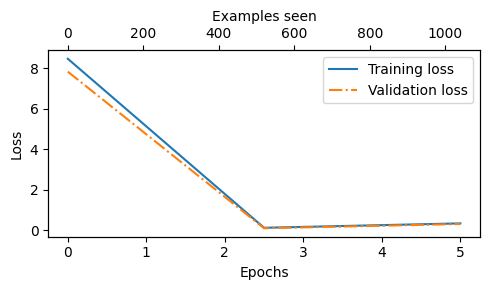

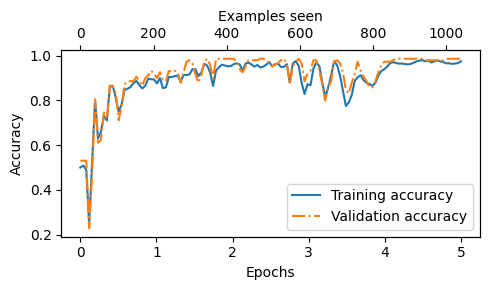

In [32]:
epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
examples_seen_tensor = torch.linspace(0, examples_seen, len(train_losses))
plot_values(epochs_tensor, examples_seen_tensor, train_losses, val_losses)

epochs_tensor = torch.linspace(0, num_epochs, len(train_acc))
examples_seen_tensor = torch.linspace(0, examples_seen, len(train_acc))

plot_values(epochs_tensor, examples_seen_tensor, train_acc, val_acc,
            label="accuracy")

In [33]:
# run evaluations post training - fine-tuning last block
torch.manual_seed(123)
with torch.no_grad():
    train_loss = calc_loss_loader(train_loader, model, device, num_batches=10)
    val_loss = calc_loss_loader(val_loader, model, device, num_batches=10)
    test_loss = calc_loss_loader(test_loader, model, device, num_batches=10)
    train_accuracy = calc_accuracy_loader(train_loader, model, device, num_batches=100)
    val_accuracy = calc_accuracy_loader(val_loader, model, device, num_batches=100)
    test_accuracy = calc_accuracy_loader(test_loader, model, device, num_batches=100)

print(f"Training loss: {train_loss:.3f}")
print(f"Validation loss: {val_loss:.3f}")
print(f"Test loss: {test_loss:.3f}")

print(f"Training accuracy: {train_accuracy*100:.2f}")
print(f"Validation accuracy: {val_accuracy*100:.2f}")
print(f"Test accuracy: {test_accuracy*100:.2f}")

Training loss: 0.251
Validation loss: 0.052
Test loss: 0.190
Training accuracy: 97.50
Validation accuracy: 98.66
Test accuracy: 96.00
